<a href="https://colab.research.google.com/github/MohHaroon/XAI-based-ZSL-for-IIDS/blob/master/ZSAL_and_SOAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of the Zero-Shot Attribution Layer and SHAP Overlap Automation Model (SOAM)

## Load CatBoost model and data splits -
### SDN Dataset

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Reloading CatBoost
from catboost import CatBoostClassifier
loaded_cat = CatBoostClassifier()
loaded_cat.load_model('/content/drive/MyDrive/IRP_Models/catboost_sdn_20260123_040438.cbm')

In [4]:
import os
import joblib
import pandas as pd

base_path = '/content/drive/MyDrive/IRP_Models/'
split_path = os.path.join(base_path, 'Data_Splits/')

X_train = joblib.load(os.path.join(split_path, f'X_train.pkl'))
X_test = joblib.load(os.path.join(split_path, f'X_test.pkl'))
y_train = joblib.load(os.path.join(split_path, f'y_train.pkl'))
y_test = joblib.load(os.path.join(split_path, f'y_test.pkl'))


# Adding the column names
feature_names = ["proto_number", "Dur", "Mean", "Stddev", "Min", "Max", "Pkts", "Bytes",
                 "Spkts", "Dpkts", "Sbytes", "Dbytes", "Srate", "Drate", "Sum",
                 "TnBPSrcIP", "TnBPDstIP", "TnP_PSrcIP", "TnP_PDstIP", "TnP_PerProto",
                 "TnP_Per_Dport", "N_IN_Conn_P_DstIP", "N_IN_Conn_P_SrcIP"]

X_test = pd.DataFrame(X_test, columns=feature_names)
X_train = pd.DataFrame(X_train, columns=feature_names)

# Align indices of y_train and y_test with the newly created DataFrames
# X_train and X_test received a new RangeIndex when converted to DataFrame.
# y_train and y_test need their indices reset to match for consistent indexing.
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"\nSuccessfully loaded Data Splits for {len(X_test)} test packets.")


Successfully loaded Data Splits for 42000 test packets.


## Zero-Shot Attribution Layer (ZSAL)

### Generating SHAP values and plot

Monitoring SDN Traffic...
ALARM: Anomaly detected at packet index 0


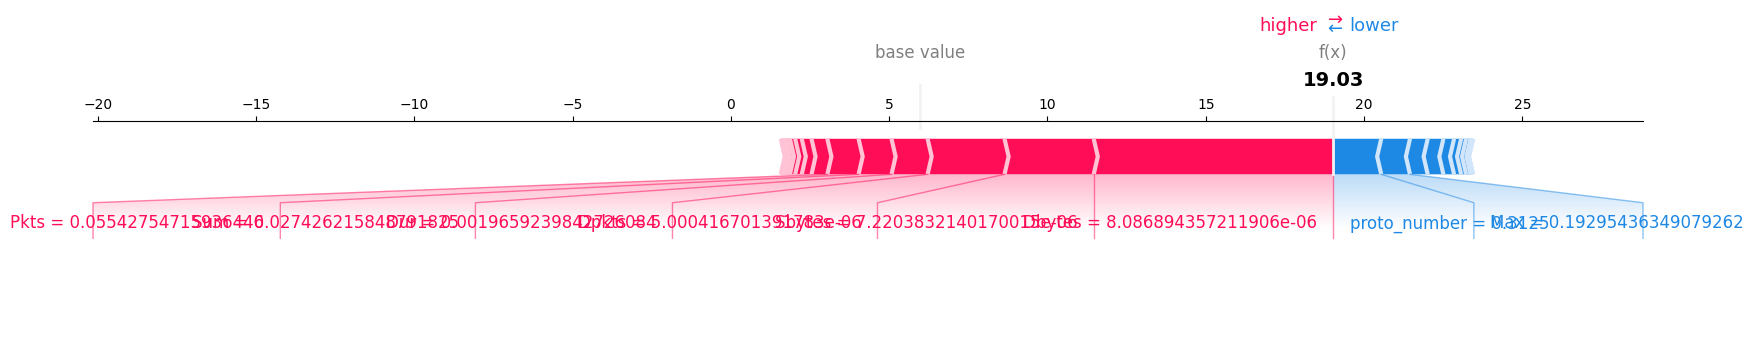

In [ ]:
import shap

# Initialize Explainer
explainer = shap.TreeExplainer(loaded_cat)

# Simulating SDIN Monitoring
print("Monitoring SDN Traffic...")
found_anomaly = False

for i in range(len(X_test)):
    # Get a single packet instance
    instance = X_test.iloc[i:i+1]

    # Inference
    prediction = loaded_cat.predict(instance)[0]

    if prediction == 1:  # Anomaly
        print(f"ALARM: Anomaly detected at packet index {i}")

        # Generate SHAP values
        instance_shap = explainer.shap_values(instance)

        shap.force_plot(explainer.expected_value, instance_shap[0], instance, matplotlib=True)

        # for ZSAL Labeling
        target_instance = instance
        target_shap = instance_shap[0]
        found_anomaly = True
        break

if not found_anomaly:
    print("No anomalies detected in the current traffic batch.")

In [ ]:
print(instance)

   proto_number       Dur      Mean    Stddev       Min       Max      Pkts  \
0        0.3125  0.001966  0.029177  0.121601  0.000411  0.192954  0.055428   

      Bytes     Spkts     Dpkts  ...     Drate       Sum  TnBPSrcIP  \
0  0.052419  0.000008  0.000005  ...  0.000012  0.027426   0.058714   

   TnBPDstIP  TnP_PSrcIP  TnP_PDstIP  TnP_PerProto  TnP_Per_Dport  \
0   0.041362    0.056576    0.056573      0.055426       0.016501   

   N_IN_Conn_P_DstIP  N_IN_Conn_P_SrcIP  
0           0.000043           0.000102  

[1 rows x 23 columns]


In [ ]:
print(target_shap)

[-1.51216400e+00  1.13995426e+00 -1.38686255e-01 -2.22529640e-01
 -8.70683341e-04 -9.08581498e-01  9.87232053e-01 -3.37505351e-01
  2.06964538e-01  2.43054045e+00  2.81709370e+00  7.57021343e+00
  9.14810218e-02 -4.95600218e-01  1.04016687e+00  1.65754870e-01
  7.82980058e-02  5.00120688e-01 -1.58382783e-01  1.22069291e-01
  3.08664532e-01 -7.86516621e-02 -5.59460870e-01]


In [ ]:
print(instance_shap)

[[-1.51216400e+00  1.13995426e+00 -1.38686255e-01 -2.22529640e-01
  -8.70683341e-04 -9.08581498e-01  9.87232053e-01 -3.37505351e-01
   2.06964538e-01  2.43054045e+00  2.81709370e+00  7.57021343e+00
   9.14810218e-02 -4.95600218e-01  1.04016687e+00  1.65754870e-01
   7.82980058e-02  5.00120688e-01 -1.58382783e-01  1.22069291e-01
   3.08664532e-01 -7.86516621e-02 -5.59460870e-01]]


In [ ]:
print(explainer.expected_value)

5.984509674509375


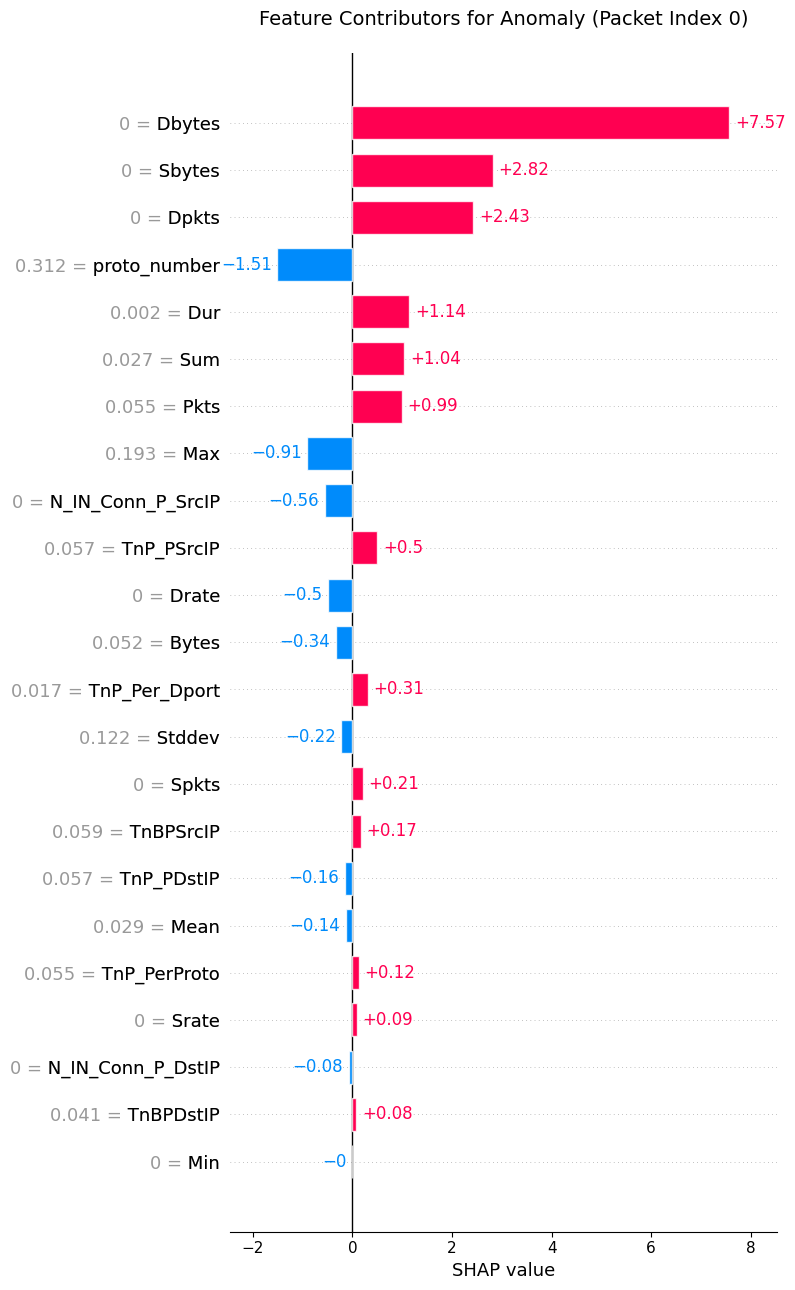

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

shap_explanation = shap.Explanation(
    values=target_shap,               # The SHAP values for this instance
    base_values=explainer.expected_value, # The average model output
    data=instance.iloc[0],         # The actual feature values for this row
    feature_names=instance.columns
)

plt.figure(figsize=(12, 8))
shap.plots.bar(shap_explanation, max_display=24, show=False)

plt.title(f"Feature Contributors for Anomaly (Packet Index {i})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Attribute the Anomaly with a label

In [34]:
def generate_zasl_label(shap_values, feature_names):

    positive_contributions = [(val, name) for val, name in zip(shap_values, feature_names) if val > 0]
    # Sort by impact (highest value first)
    sorted_contributions = sorted(positive_contributions, key=lambda x: x[0], reverse=True)

    # Extract top features
    top_features = [item[1] for item in sorted_contributions[:3]]
    high_impact_extra = [item[1] for item in sorted_contributions[3:] if item[0] > 2]

    final_feature_list = top_features + high_impact_extra

    if not top_features:
        return "Generic Anomaly"

    return f"{'-'.join(final_feature_list)}-based-Attribution"

zasl_name = generate_zasl_label(target_shap, feature_names)
print(f"ZASL Final Label: {zasl_name}")

ZASL Final Label: TnP_Per_Dport-Spkts-Srate-based-Attribution


## SHAP Overlap Automation Model (SOAM)

### Generate mean SHAP values for TP and FP

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

train_subset = X_train.sample(35000, random_state=42)
train_subset_labels = y_train.loc[train_subset.index]
shap_values_train = explainer.shap_values(train_subset)

# 2. Segment indices based on model performance on the training data
# Use the correct model object: `loaded_cat` instead of `cat_model`
train_preds = loaded_cat.predict(train_subset)
tp_indices = np.where((train_preds == 1) & (train_subset_labels == 1))[0]
fp_indices = np.where((train_preds == 1) & (train_subset_labels == 0))[0]

# 3. Calculate the Mean SHAP Profiles (The "Reference Knowledge")
tp_mean_profile = shap_values_train[tp_indices].mean(axis=0)
fp_mean_profile = shap_values_train[fp_indices].mean(axis=0)

print(f"SOAM Baselines Created: {len(tp_indices)} TPs and {len(fp_indices)} FPs utilized.")

SOAM Baselines Created: 29147 TPs and 329 FPs utilized.


In [10]:
# 1. Identify indices for correctly classified Normal traffic in the training subset
# Assumes you have train_preds and train_subset_labels from our previous step
tn_indices = np.where((train_preds == 0) & (train_subset_labels == 0))[0]

# 2. Calculate the Mean Normal SHAP Profile
normal_mean_profile = shap_values_train[tn_indices].mean(axis=0)

soam_path = '/content/drive/MyDrive/IRP_Models/SOAM_Baselines/'
# 3. Save it to your SOAM Baselines folder
joblib.dump(normal_mean_profile, f'{soam_path}normal_mean_profile.pkl')

print(f"Final SOAM Baseline Created: {len(tn_indices)} True Negatives utilized.")

Final SOAM Baseline Created: 5464 True Negatives utilized.


In [20]:
fn_indices = np.where((train_preds == 0) & (train_subset_labels == 1))[0]

# 2. Calculate the Mean Normal SHAP Profile
fn_mean_profile = shap_values_train[fn_indices].mean(axis=0)
print(f"Final SOAM Baseline Created: {len(fn_indices)} False Negatives utilized.")

Final SOAM Baseline Created: 60 False Negatives utilized.


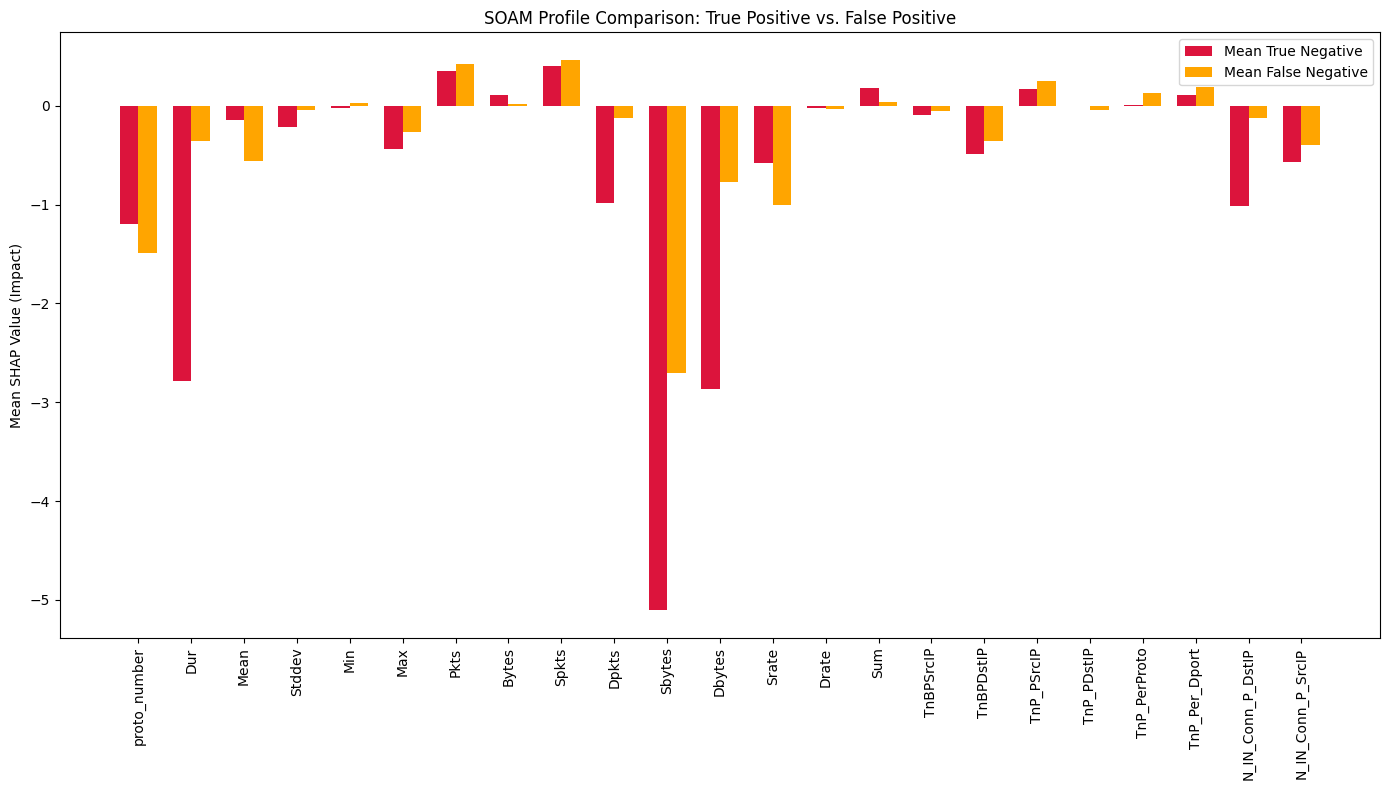

In [23]:
# 4. Comparative Bar Plot for SOAM Diagnosis
feature_names = X_train.columns
x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
rects1 = ax.bar(x - width/2, normal_mean_profile, width, label='Mean True Negative', color='crimson')
rects4 = ax.bar(x + width/2, fn_mean_profile, width, label='Mean False Negative', color='orange')

ax.set_ylabel('Mean SHAP Value (Impact)')
ax.set_title('SOAM Profile Comparison: True Positive vs. False Positive')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

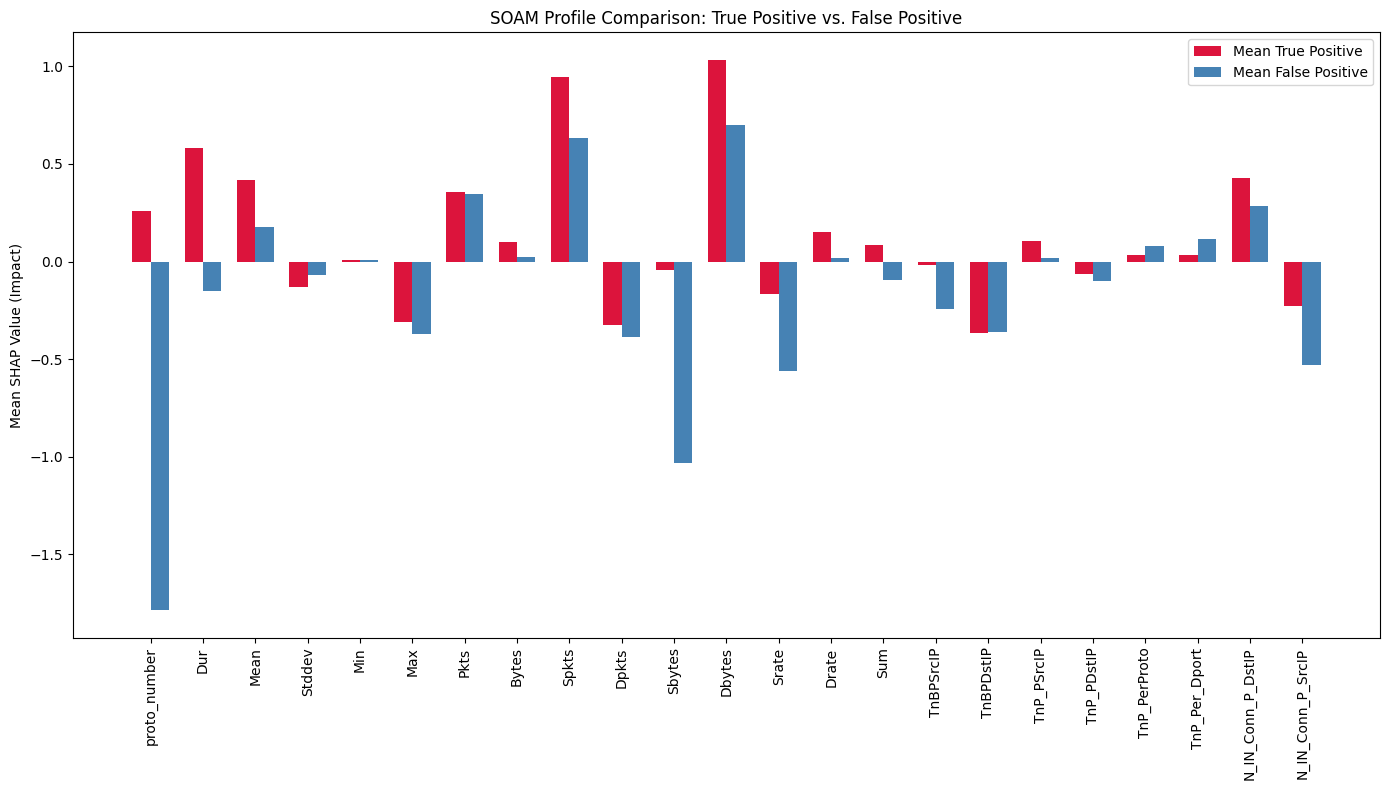

In [ ]:
# 4. Comparative Bar Plot for SOAM Diagnosis
feature_names = X_train.columns
x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
rects1 = ax.bar(x - width/2, tp_mean_profile, width, label='Mean True Positive', color='crimson')
rects2 = ax.bar(x + width/2, fp_mean_profile, width, label='Mean False Positive', color='steelblue')

ax.set_ylabel('Mean SHAP Value (Impact)')
ax.set_title('SOAM Profile Comparison: True Positive vs. False Positive')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

### Save Mean SHAP values

In [ ]:
import joblib
import os
from datetime import datetime

# 1. Setup the save path specifically for SOAM Baselines
soam_path = '/content/drive/MyDrive/IRP_Models/SOAM_Baselines/'
if not os.path.exists(soam_path):
    os.makedirs(soam_path)

# 2. Use the same timestamp logic for consistency
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 3. Save the Mean Profiles (The "Gold Standard")
joblib.dump(tp_mean_profile, f'{soam_path}tp_mean_profile_{timestamp}.pkl')
joblib.dump(fp_mean_profile, f'{soam_path}fp_mean_profile_{timestamp}.pkl')

print(f"SOAM Baseline Profiles saved successfully at: {soam_path}")
print(f"Timestamp: {timestamp}")

SOAM Baseline Profiles saved successfully at: /content/drive/MyDrive/IRP_Models/SOAM_Baselines/
Timestamp: 20260129_011503


In [14]:
# Loading back for the final similarity check
tp_mean = joblib.load(f'{soam_path}tp_mean_profile_20260129_011503.pkl')
fp_mean = joblib.load(f'{soam_path}fp_mean_profile_20260129_011503.pkl')

### Calculate Confidence

In [25]:
#2nd func
def calculate_weighted_soam(instance_shap, mean_profile):
    from scipy.spatial.distance import cosine
    from scipy.stats import spearmanr
    import numpy as np

    # 1. Cosine Similarity (Weight: 50%)
    cos_sim = 1 - cosine(instance_shap, mean_profile)

    # 2. Spearman Rank Correlation (Weight: 25%)
    spearman_corr, _ = spearmanr(instance_shap, mean_profile)

    # Calculate absolute differences for each feature
    absolute_diffs = np.abs(instance_shap - mean_profile)
    # Calculate the mean of these differences
    mad_score = np.mean(absolute_diffs)

    # 3. Jaccard-style Sign Overlap (Weight: 25%)
    instance_signs = np.sign(instance_shap)
    mean_signs = np.sign(mean_profile)
    sign_overlap = (instance_signs == mean_signs).mean()

    # 4. Final Weighted Aggregation
    # Formula: (0.5 * Cosine) + (0.25 * Spearman) + (0.25 * SignOverlap)
    weighted_score = (0.70 * cos_sim) + (0.1 * spearman_corr) + (0.1 * sign_overlap) + (0.1 * mad_score)


    return {
        "Cosine": cos_sim,
        "Spearman": spearman_corr,
        "Sign_Overlap": sign_overlap,
        "MAD": mad_score,
        "Weighted_Reliability": weighted_score
    }

In [26]:
def get_soam_verdict(instance_shap, tp_mean, fp_mean):


    # Calculate scores for both reference groups
    tp_scores = calculate_weighted_soam(instance_shap, tp_mean)
    print("Cosine, SPearman, Sign_Overlap, MAD for tp", tp_scores['Cosine'], tp_scores['Spearman'], tp_scores['Sign_Overlap'],tp_scores['MAD'])

    fp_scores = calculate_weighted_soam(instance_shap, fp_mean)
    print("Cosine, SPearman, Sign_Overlap, MAD for fp", fp_scores['Cosine'], fp_scores['Spearman'], fp_scores['Sign_Overlap'], fp_scores['MAD'])

    tp_rel = tp_scores['Weighted_Reliability']
    fp_rel = fp_scores['Weighted_Reliability']

    # Logic to determine the final system action
    if tp_rel > fp_rel and (tp_rel-fp_rel) > 0.15:
        verdict = f"CONFIRMED ATTACK, confidence score = {tp_rel:.2%}"
        action = "Automated Mitigation Triggered"
    elif fp_rel > tp_rel:
        verdict = f"POTENTIAL FALSE Alarm = {fp_rel:.2%}"
        action = "Flagged for Human Review"
    else:
        verdict = "Potential Attack, Analyst Required"
        action = "Flagged for Human Review"

    return {
        "Verdict": verdict,
        "Action": action,
        "TP_Similarity": tp_rel,
        "FP_Similarity": fp_rel
    }

In [ ]:
# Execute the final component check
verdict_results = get_soam_verdict(target_shap, tp_mean_profile, fp_mean_profile)
print(f"Final System Verdict: {verdict_results['Verdict']}")
print(f"Action: {verdict_results['Action']}")

Cosine, SPearman, Sign_Overlap, MAD for tp 0.4982250737819707 0.2233201581027668 0.5217391304347826 0.9440382623246305
Cosine, SPearman, Sign_Overlap, MAD for fp 0.21511317771373428 0.2015810276679842 0.4782608695652174 0.9508155537538675
Final System Verdict: CONFIRMED ATTACK, confidence score = 51.77%
Action: Automated Mitigation Triggered


In [ ]:
import time
import pandas as pd
import numpy as np
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr

def automated_stress_test(X_test, y_test, model, explainer, tp_ref, fp_ref, n_instances=50):
    results = []

    # Identify indices for 50 True Positives and 50 False Positives
    preds = model.predict(X_test)
    tp_pool = np.where((preds == 1) & (y_test == 1))[0][:n_instances]
    fp_pool = np.where((preds == 1) & (y_test == 0))[0][:n_instances]
    test_indices = np.concatenate([tp_pool, fp_pool])

    print(f"Starting Stress Test on {len(test_indices)} packets...")

    for idx in test_indices:
        start_time = time.time()

        # 1. Inference Latency (Component 2)
        instance = X_test.iloc[idx:idx+1]
        model.predict(instance)
        inference_end = time.time()

        # 2. XAI Latency (Component 3 & 4)
        shap_values = explainer.shap_values(instance)[0]
        zasl_label = generate_zasl_label(shap_values, X_test.columns.tolist())
        xai_end = time.time()

        # 3. SOAM Latency (Component 5)
        tp_metrics = calculate_weighted_soam(shap_values, tp_ref)
        fp_metrics = calculate_weighted_soam(shap_values, fp_ref)
        soam_end = time.time()

        # Calculate individual latencies in milliseconds
        latency_inf = (inference_end - start_time) * 1000
        latency_xai = (xai_end - inference_end) * 1000
        latency_soam = (soam_end - xai_end) * 1000
        total_latency = (soam_end - start_time) * 1000


        if tp_metrics > fp_metrics and (tp_metrics-fp_metrics) > 0.15:
          verdict = f"CONFIRMED ATTACK, confidence score = {tp_metrics:.2%}"
          action = "Automated Mitigation Triggered"
        elif fp_metrics > tp_metrics:
          verdict = f"POTENTIAL FALSE Alarm = {fp_metrics:.2%}"
          action = "Flagged for Human Review"
        else:
          verdict = "Potential Attack, Analyst Required"
          action = "Flagged for Human Review"


        results.append({
            'index': idx,
            'ground_truth': 'TP' if idx in tp_pool else 'FP',
            'zasl_label': zasl_label,
            'tp_cosine': tp_metrics['Cosine'],
            'fp_cosine': fp_metrics['Cosine'],
            'tp_reliability': tp_metrics['Weighted_Reliability'],
            'fp_reliability': fp_metrics['Weighted_Reliability'],
            'latency_ms': total_latency,
            'inf_ms': latency_inf,
            'xai_ms': latency_xai,
            'soam_ms': latency_soam,
            'verdict': verdict,
            'action': action
        })

    return pd.DataFrame(results)

# Run the test
stress_test_df = automated_stress_test(X_test, y_test, loaded_cat, explainer, tp_mean_profile, fp_mean_profile)
stress_test_df.to_csv('SDIN_Framework_StressTest_Results.csv', index=False)
print("Stress Test Complete. Results saved to CSV.")

Starting Stress Test on 100 packets...


TypeError: '>' not supported between instances of 'dict' and 'dict'

Analyzing 100 packets for Reliability Gap...


/tmp/ipython-input-16203319.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Ground Truth', y='TP_Similarity_Score', data=stress_df, palette=palette, width=0.5)


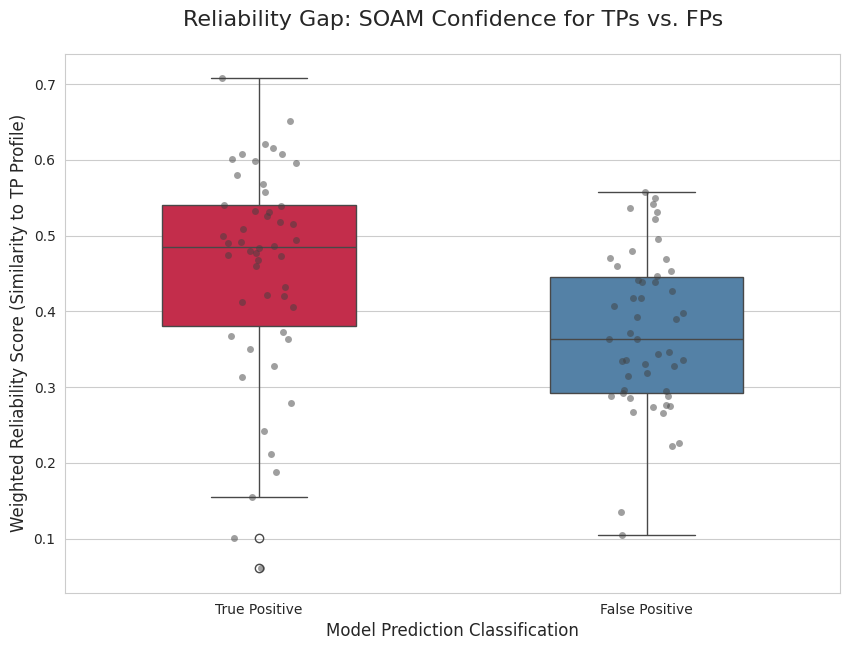

Mean Reliability Gap: 0.0834


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Select 50 TPs and 50 FPs from the Test Set
test_preds = loaded_cat.predict(X_test)
tp_indices = np.where((test_preds == 1) & (y_test == 1))[0][:50]
fp_indices = np.where((test_preds == 1) & (y_test == 0))[0][:50]

all_test_indices = np.concatenate([tp_indices, fp_indices])
stress_results = []

print("Analyzing 100 packets for Reliability Gap...")

# 2. Automated Loop for Metrics
for idx in all_test_indices:
    instance = X_test.iloc[idx:idx+1]
    # Use the existing explainer and profiles
    instance_shap = explainer.shap_values(instance)[0]

    # Calculate Similarity to 'Gold Standard' TP Profile
    tp_metrics = calculate_weighted_soam(instance_shap, tp_mean_profile)

    stress_results.append({
        'Ground Truth': 'True Positive' if idx in tp_indices else 'False Positive',
        'TP_Similarity_Score': tp_metrics['Weighted_Reliability']
    })

stress_df = pd.DataFrame(stress_results)

# 3. Create the Visualization
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
palette = {"True Positive": "crimson", "False Positive": "steelblue"}

ax = sns.boxplot(x='Ground Truth', y='TP_Similarity_Score', data=stress_df, palette=palette, width=0.5)
sns.stripplot(x='Ground Truth', y='TP_Similarity_Score', data=stress_df, color=".25", alpha=0.5)

plt.title('Reliability Gap: SOAM Confidence for TPs vs. FPs', fontsize=16, pad=20)
plt.ylabel('Weighted Reliability Score (Similarity to TP Profile)', fontsize=12)
plt.xlabel('Model Prediction Classification', fontsize=12)

# Save for your final report
plt.savefig('SOAM_Reliability_Gap.png', dpi=300)
plt.show()

# Print the Mean Gap for your Results section
mean_tp = stress_df[stress_df['Ground Truth'] == 'True Positive']['TP_Similarity_Score'].mean()
mean_fp = stress_df[stress_df['Ground Truth'] == 'False Positive']['TP_Similarity_Score'].mean()
print(f"Mean Reliability Gap: {mean_tp - mean_fp:.4f}")

# Validate Normal Traffic

Monitoring SDN Traffic...
ALARM: Anomaly detected at packet index 8


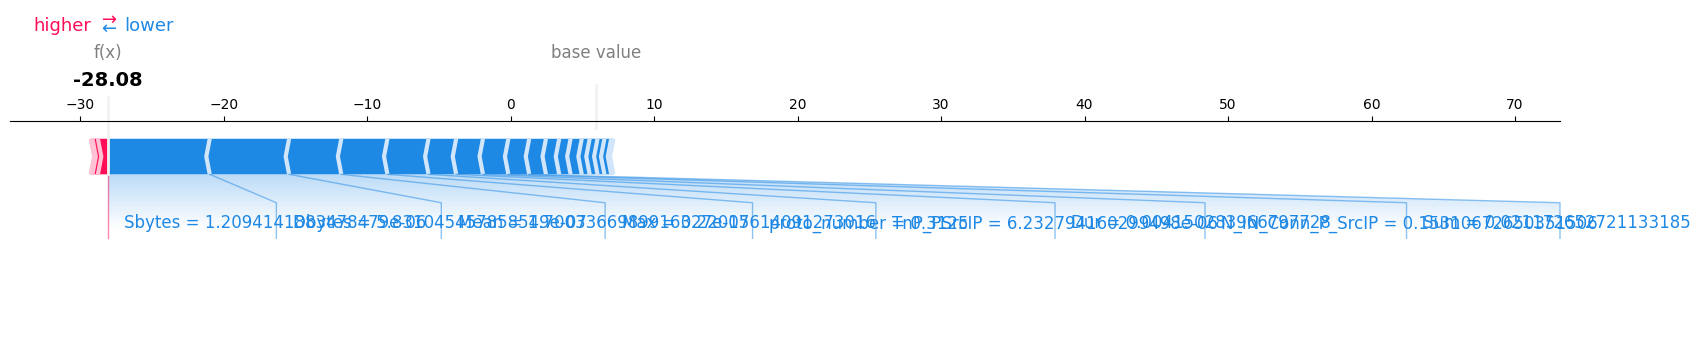

In [5]:
##Normal Traffic

import shap

# Initialize Explainer
explainer = shap.TreeExplainer(loaded_cat)

# Simulating SDIN Monitoring
print("Monitoring SDN Traffic...")
found_anomaly = False

for i in range(len(X_test)):
    # Get a single packet instance
    instance = X_test.iloc[i:i+1]

    # Inference
    prediction = loaded_cat.predict(instance)[0]

    if prediction == 0:  # Anomaly
        print(f"ALARM: Anomaly detected at packet index {i}")

        # Generate SHAP values
        instance_shap = explainer.shap_values(instance)

        shap.force_plot(explainer.expected_value, instance_shap[0], instance, matplotlib=True)

        # for ZSAL Labeling
        target_instance = instance
        target_shap = instance_shap[0]
        found_anomaly = True
        break

if not found_anomaly:
    print("No anomalies detected in the current traffic batch.")

In [6]:
print(instance)

   proto_number      Dur      Mean    Stddev  Min       Max     Pkts  \
8        0.3125  0.00415  0.000017  0.002777  0.0  0.220176  0.03668   

      Bytes     Spkts     Dpkts  ...     Drate       Sum  TnBPSrcIP  \
8  0.058352  0.000008  0.000005  ...  0.000012  0.021173   0.000011   

   TnBPDstIP  TnP_PSrcIP  TnP_PDstIP  TnP_PerProto  TnP_Per_Dport  \
8   0.052622    0.000006    0.042786      0.036678       0.011913   

   N_IN_Conn_P_DstIP  N_IN_Conn_P_SrcIP  
8           0.080664           0.153107  

[1 rows x 23 columns]


In [7]:
print(explainer.expected_value)

5.984509674509375


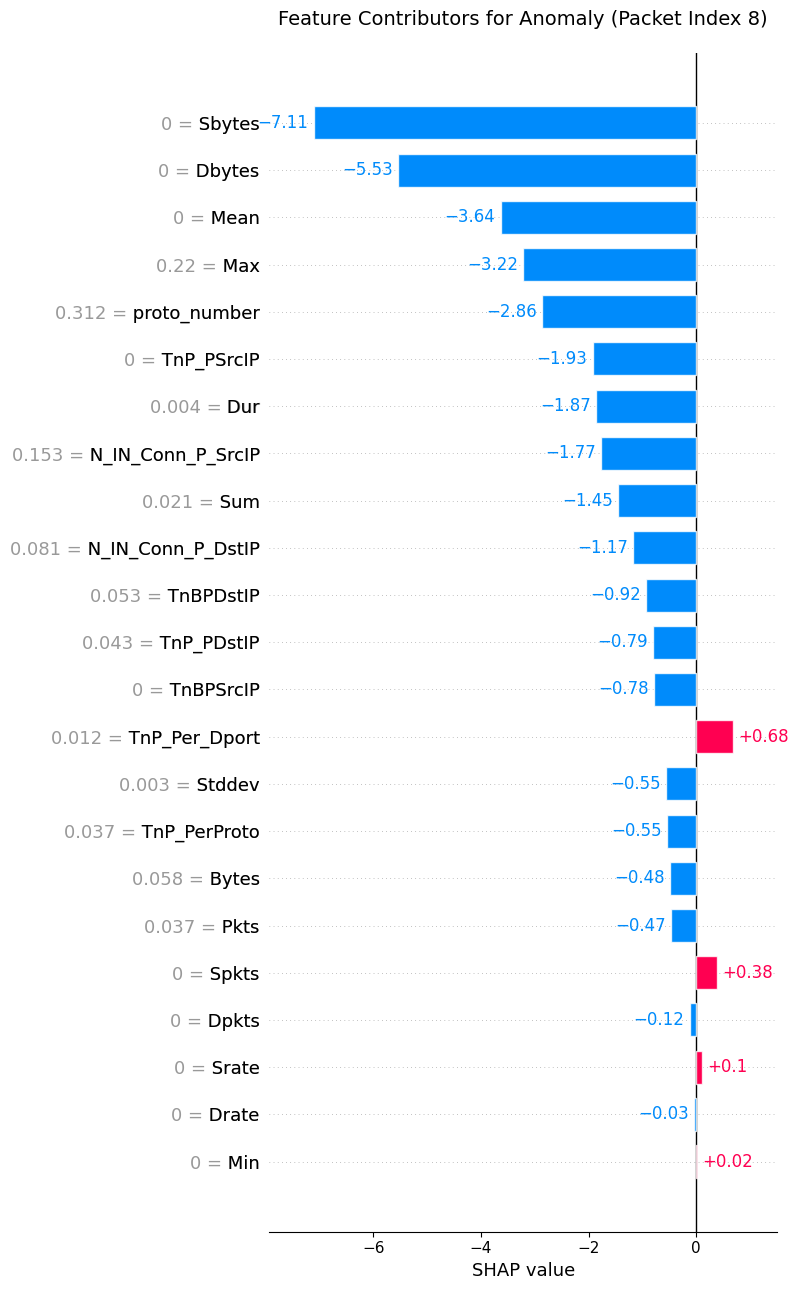

In [8]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

shap_explanation = shap.Explanation(
    values=target_shap,               # The SHAP values for this instance
    base_values=explainer.expected_value, # The average model output
    data=instance.iloc[0],         # The actual feature values for this row
    feature_names=instance.columns
)

plt.figure(figsize=(12, 8))
shap.plots.bar(shap_explanation, max_display=24, show=False)

plt.title(f"Feature Contributors for Anomaly (Packet Index {i})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [30]:
def check_normal_integrity(instance_shap, normal_mean, fp_mean):
    # Calculate similarity to Normal baseline
    normal_sim = calculate_weighted_soam(instance_shap, normal_mean)['Weighted_Reliability']
    # Calculate similarity to False Positive (Missed Attack) baseline
    fp_sim = calculate_weighted_soam(instance_shap, fp_mean)['Weighted_Reliability']
    print(f"Similarity to Normal Baseline: {normal_sim:.4f}")
    print(f"Similarity to False Positive (Missed Attack) Baseline: {fp_sim:.4f}")

    if fp_sim > normal_sim and fp_sim > 0.4:
      #add label for zasl
        return "SUSPECT NORMAL (Potential False Negative)", "Flag for Manual Review"
    return "RELIABLE NORMAL", "No Action Required"

In [31]:
print(check_normal_integrity(target_shap, normal_mean_profile, fp_mean))

Similarity to Normal Baseline: 0.8073
Similarity to False Positive (Missed Attack) Baseline: 0.4914
('RELIABLE NORMAL', 'No Action Required')


#Simulation

In [32]:
import time
import pandas as pd
import numpy as np
from datetime import datetime

def run_sdin_cli_simulation(X_test, y_test, model, explainer, profiles, num_packets=10):
    """
    Simulates a live CLI monitoring tool for an Industrial SDN.
    """
    print("="*80)
    print(f" SDIN SECURITY MONITOR - X-IDS PROTOCOLE | START TIME: {datetime.now().strftime('%H:%M:%S')}")
    print("="*80)
    print(f"{'TIMESTAMP':<12} | {'RESULT':<8} | {'CONFIDENCE':<10} | {'VERDICT/LABEL'}")
    print("-"*80)

    # Randomly sample packets to simulate live traffic
    samples = X_test.sample(num_packets)

    for i, (idx, row) in enumerate(samples.iterrows()):
        packet = row.values.reshape(1, -1)
        packet_df = pd.DataFrame([row], columns=X_test.columns)

        # 1. Model Prediction
        pred = model.predict(packet_df)[0]

        # 2. XAI Processing
        shap_vals = explainer.shap_values(packet_df)[0]

        timestamp = datetime.now().strftime('%H:%M:%S')

        if pred == 1:
            # ATTACK PATH
            label = generate_zasl_label(shap_vals, X_test.columns.tolist())
            verdict = get_soam_verdict(shap_vals, profiles['tp_mean'], profiles['fp_mean'])

            # Clean up verdict string for CLI display
            status = "\033[91mATTACK\033[0m" # Red Text
            conf = f"{verdict['TP_Similarity']:.2%}"
            details = f"[{label}] -> {verdict['Verdict']}"
        else:
            # NORMAL PATH
            # Simplified integrity check for CLI
            normal_sim = calculate_weighted_soam(shap_vals, profiles['normal_mean'])['Weighted_Reliability']
            status = "\033[92mNORMAL\033[0m" # Green Text
            conf = f"{normal_sim:.2%}"
            details = "Reliable Traffic"

            # Catch "Suspect Normal" cases
            fp_sim = calculate_weighted_soam(shap_vals, profiles['fp_mean'])['Weighted_Reliability']
            if fp_sim > normal_sim and fp_sim > 0.4:
                status = "\033[93mSUSPECT\033[0m" # Yellow Text
                details = "ALERT: Suspect Normal (Possible False Negative)"

        print(f"{timestamp:<12} | {status:<17} | {conf:<10} | {details}")

        # Simulate network delay
        time.sleep(0.8)

    print("-"*80)
    print("SIMULATION COMPLETE | ALL PACKETS PROCESSED")
    print("="*80)

# Setup Profiles for the CLI
profile_store = {
    'tp_mean': tp_mean_profile,
    'fp_mean': fp_mean_profile,
    'normal_mean': normal_mean_profile
}

# Run the CLI

In [35]:

run_sdin_cli_simulation(X_test, y_test, loaded_cat, explainer, profile_store, num_packets=15)

 SDIN SECURITY MONITOR - X-IDS PROTOCOLE | START TIME: 09:56:20
TIMESTAMP    | RESULT   | CONFIDENCE | VERDICT/LABEL
--------------------------------------------------------------------------------
Cosine, SPearman, Sign_Overlap, MAD for tp 0.38527332733560327 0.46640316205533605 0.6521739130434783 0.7004455278181133
Cosine, SPearman, Sign_Overlap, MAD for fp 0.21632627397258886 0.3290513833992095 0.6086956521739131 0.7194379172894645
09:56:20     | ATTACK   | 45.16%     | [Sbytes-Drate-Dbytes-based-Attribution] -> Potential Attack, Analyst Required
Cosine, SPearman, Sign_Overlap, MAD for tp 0.0655770303195059 0.07509881422924902 0.6086956521739131 0.9307110257713005
Cosine, SPearman, Sign_Overlap, MAD for fp -0.5159104281223117 -0.024703557312252968 0.5652173913043478 1.0490409586417826
09:56:21     | ATTACK   | 20.74%     | [proto_number-TnP_Per_Dport-Spkts-based-Attribution] -> CONFIRMED ATTACK, confidence score = 20.74%
Cosine, SPearman, Sign_Overlap, MAD for tp 0.7186831145434024 